# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [ ] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [ ] change OS to 1/10,
- [ ] 1/10 OS and scf bop
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [4]:
DS = Dataset('Fe-Mo')

# Targets

Text(0.5, 0, '$V_0$')

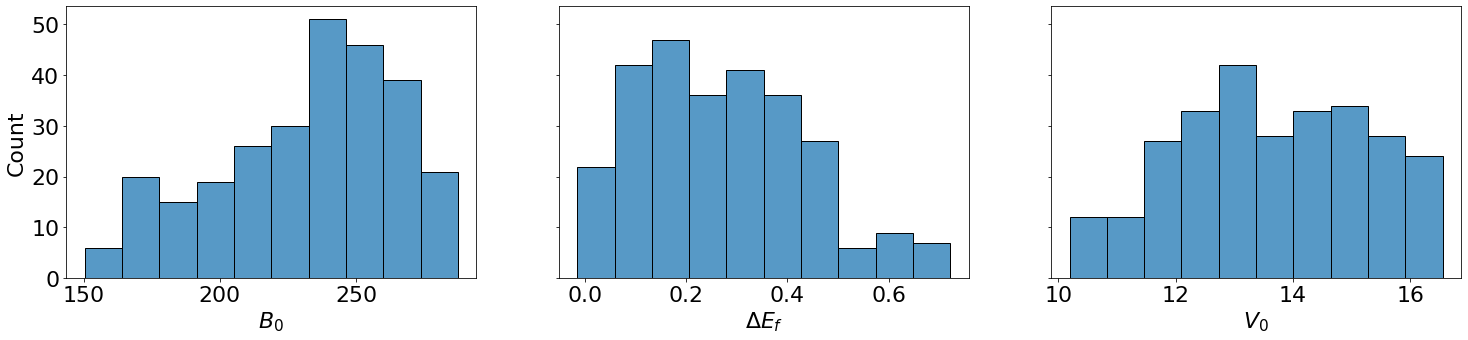

In [5]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS['EF'], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel('$\Delta E_f$')
ax[2].set_xlabel('$V_0$')

# Machine Learning 

In [6]:
from Tools.DatasetTools.MLConveniences import *

In [7]:
resultslocation = DS.resultslocation

## Feature sets

In [8]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [9]:
Features['Canonical BOP']

,Structure,Mag,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,10,0,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,10,0,-78.594335,-7.771059,-1.424594,0.000000,-5.906606,-0.439859,0.000000,1.201761,...,0.000000,0.668575,0.166260,0.000000,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,0,-94.449166,-8.534487,-7.595698,0.000000,0.000000,0.000000,-0.938789,1.303069,...,0.000000,0.000000,0.000000,0.501537,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327
Fe_pv5Mo_sv24.chi-AABB.FM,6,0,-116.205661,-8.244366,-6.070495,-1.652565,0.000000,0.000000,-0.521305,1.162619,...,0.451346,0.000000,0.000000,0.186186,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,1,-121.105805,-8.136275,-2.533063,0.000000,-0.844603,-0.318349,-4.440260,1.218738,...,0.000000,0.256809,0.124851,0.170809,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,9,1,-40.035290,-8.020136,-2.520056,0.000000,-0.663807,-0.397166,-4.439107,1.265062,...,0.000000,0.220371,0.224323,0.222761,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884
Fe_pv8Mo_sv22.sigma-BBABB.NM,10,1,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,7,0,-12.617373,-6.832601,-6.832601,0.000000,0.000000,0.000000,0.000000,1.063750,...,0.000000,0.000000,0.000000,0.000000,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,10,0,-94.569986,-7.892530,-5.305761,0.000000,-2.136368,-0.450401,0.000000,1.174563,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000


In [10]:
Features.keys()

dict_keys(['atomic', 'dataset', 'Pyscal', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', 'Projections sOS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + Projections sOS BOP'])

## BOP features with and without CP averages

In [11]:
def clean_CNAVS(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [12]:
def clean_zeros(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [13]:
def notyetclean(name:str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [14]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name) } )

In [15]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [16]:
samplesplit = DS.get_samplesplit()

# Models: adjust params

In [17]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
}

In [18]:
Parameters = {
    'Kernel Ridge': {'regressor__alpha':[0.1, 0.01,0.001, 1e-4],
                     'regressor__kernel':['rbf', 'polynomial'], 
                     'regressor__degree': [4,5,6,7],
                     'regressor__coef0': [0, 1, 10],
                    }
}

In [19]:
samplefolds = list(DS.get_folds())

# fits

In [20]:
FittedModels = {}

In [21]:
Models

{'Kernel Ridge': Pipeline(steps=[('scaler', StandardScaler()), ('regressor', KernelRidge())])}

In [22]:
for name, model in Models.items():
    print (name)
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        if 'no CNAV' in key:
            continue
        model = GridSearchCV(
            Models[name],
            Parameters[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        FittedModels[(name, key)] = model.fit(features, DS.target)

Kernel Ridge


  0%|          | 0/19 [00:00<?, ?it/s]

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits


In [23]:
best_scores = {}
for (modelname, featurename), fittedmodel in FittedModels.items():
    best_scores[(modelname, featurename)] = {'test': abs(fittedmodel.best_score_)}
best_scores = pd.DataFrame.from_dict(best_scores, orient='index')
best_scores.index = pd.MultiIndex.from_tuples(best_scores.index)
best_scores.sort_values(by='test', ascending=True, inplace=True)
best_scores.sort_index(level=0, sort_remaining=False, ascending=True, inplace=True)

In [24]:
best_scores.idxmin()

test    (Kernel Ridge, dataset + Projections OS BOP)
dtype: object

In [25]:
best_combi = best_scores.idxmin()['test']

In [26]:
best_combi

('Kernel Ridge', 'dataset + Projections OS BOP')

In [27]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)

In [28]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [29]:
results['mean_test_score'].idxmin()

7

In [30]:
results['mean_test_score'].loc[7]

-0.3087058317020097

In [31]:
best_scores.loc[best_combi]

test    0.036011
Name: (Kernel Ridge, dataset + Projections OS BOP), dtype: float64

In [32]:
results.loc[7].params

{'regressor__alpha': 0.1,
 'regressor__coef0': 0,
 'regressor__degree': 7,
 'regressor__kernel': 'polynomial'}

In [33]:
for parameters in Parameters.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

param_regressor__alpha
0.0001   -0.043988
0.0010   -0.039161
0.0100   -0.036540
0.1000   -0.036011
Name: mean_test_score, dtype: float64
param_regressor__kernel
polynomial   -0.036011
rbf          -0.056060
Name: mean_test_score, dtype: float64
param_regressor__degree
4   -0.036540
5   -0.036011
6   -0.036554
7   -0.037906
Name: mean_test_score, dtype: float64
param_regressor__coef0
0    -0.056060
1    -0.036011
10   -0.047576
Name: mean_test_score, dtype: float64


In [34]:
FittedModels[best_combi].best_params_

{'regressor__alpha': 0.1,
 'regressor__coef0': 1,
 'regressor__degree': 5,
 'regressor__kernel': 'polynomial'}

(0.0, 0.1)

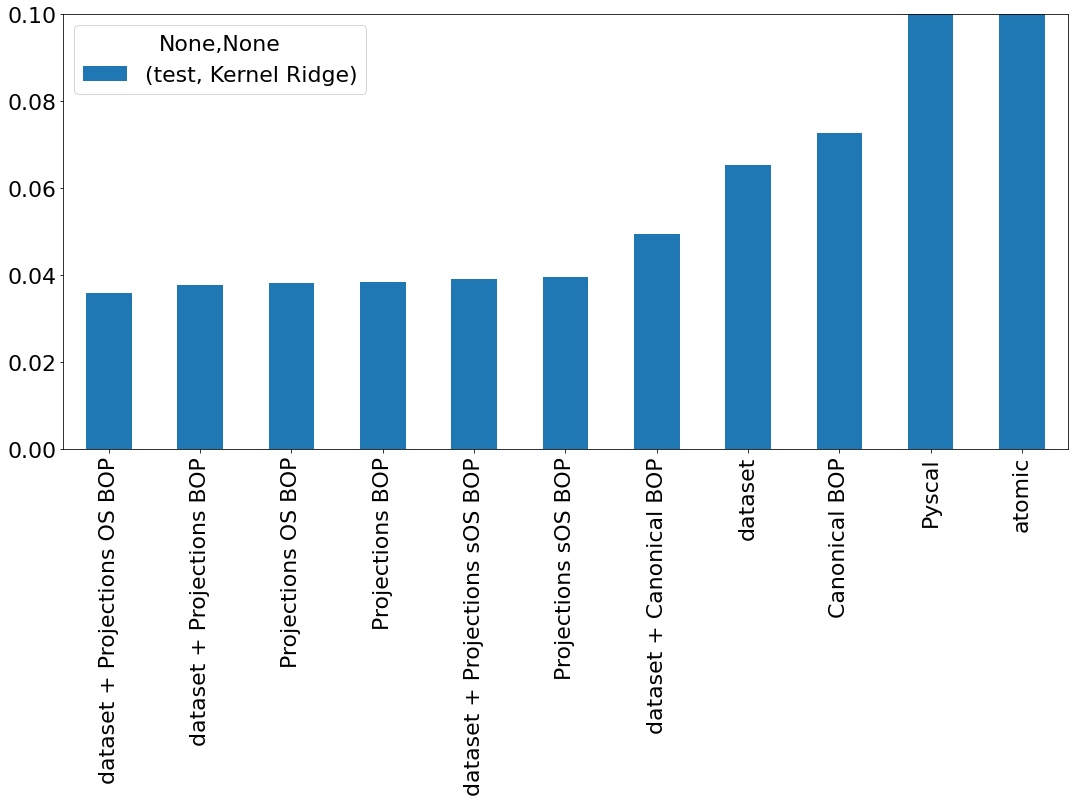

In [35]:
ax = best_scores.unstack(level=0).sort_values(by=('test','Kernel Ridge')).plot.bar()
ax.set_ylim([0,0.1])


# Recursivity

In [43]:
Tester = DatasetTester()

In [44]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#from Tools.DatasetTools.DatasetOperator import Dataset
#DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
#Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#samplesplit = DS.get_samplesplit()

In [45]:
test_scores = Tester.make_recursivity_anbn(DS, FittedModels, {'includemag':False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Tools/DatasetTools/DatasetOperator.py:216: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  axes.plot(


(<Figure size 1296x576 with 1 Axes>,
 <AxesSubplot:xlabel='number of features', ylabel='test RMSE @ $\\Delta E_f$'>)

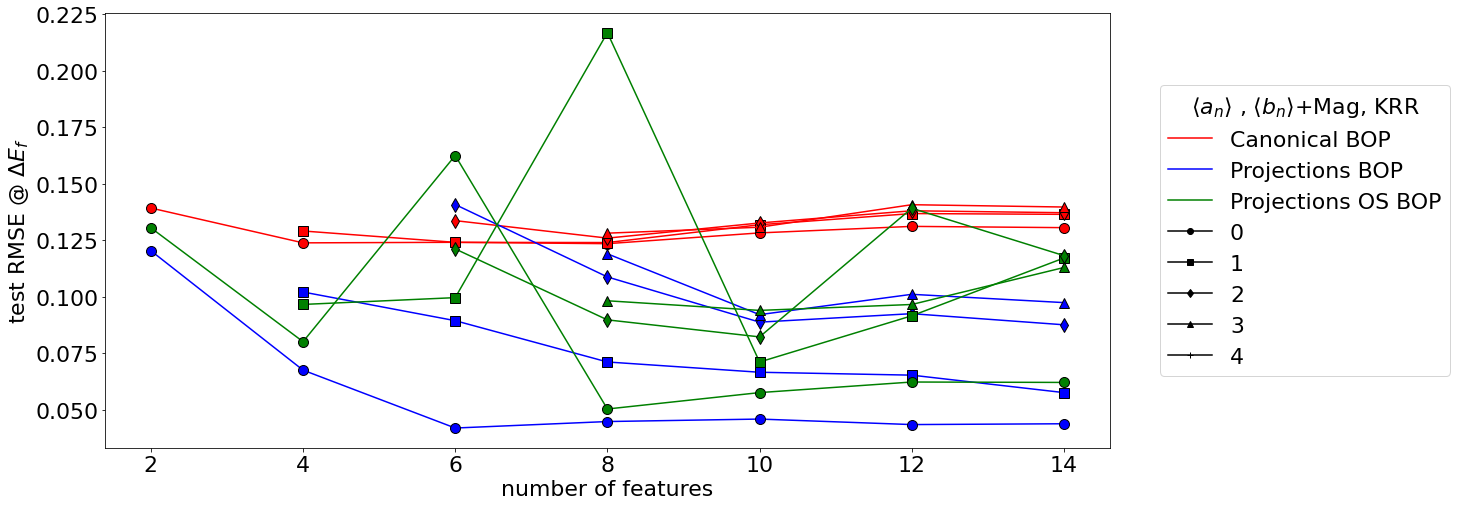

In [46]:
Tester.plot_recursivity_curve(test_scores, 'Kernel Ridge', )

In [ ]:
fig.savefig(f'{DS.dataset}/graphs/KRR_recursivity_anbn.pdf', bbox_inches='tight')